# Adaptive Gradient Descent (non-descent) vs GD / Backtracking / AGD

This notebook implements **Adaptive Gradient Descent without descent** using the **Barzilai-Borwein (BB)** step sizes (no line search, so the method is not monotone), and compares it to:

- Gradient Descent with constant step $1/L$,
- Gradient Descent with Armijo backtracking,
- Nesterov's Accelerated Gradient Descent (AGD).

**Metric**: we plot $f(x_k)-f(x^\star)$ (semilogy) vs iterations, under the same data-generation setup as in Assignment 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_data(m, n, sigma=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(m) * sigma
    b = A @ w_true + noise
    return A, b

def f_val(A, b, x):
    r = A @ x - b
    return float(r @ r)

def grad(A, b, x):
    r = A @ x - b
    return 2 * (A.T @ r)

def L_lipschitz(A):
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2.0 * (smax**2)

def solve_star(A, b):
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    return x_star


In [2]:
def gd_constant(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    vals = []
    for _ in range(iters):
        vals.append(f_val(A, b, x))
        x -= t * grad(A, b, x)
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def gd_backtracking(A, b, x0, iters, t0=None, beta=0.8, c=1e-4):
    if t0 is None:
        t0 = 1.0 / L_lipschitz(A)
    x = x0.copy()
    vals = []
    for _ in range(iters):
        fx = f_val(A, b, x)
        vals.append(fx)
        g = grad(A, b, x)
        t = t0
        g2 = float(g @ g)
        while True:
            x_new = x - t * g
            if f_val(A, b, x_new) <= fx - c * t * g2:
                break
            t *= beta
        x = x_new
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def accel_gd(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    y = x0.copy()
    vals = []
    for k in range(1, iters + 1):
        vals.append(f_val(A, b, x))
        g = grad(A, b, y)
        x_next = y - t * g
        theta = (k - 1) / (k + 2)
        y = x_next + theta * (x_next - x)
        x = x_next
    vals.append(f_val(A, b, x))
    return x, np.array(vals)


## Adaptive Gradient Descent without descent (Barzilai-Borwein)

We use the BB step sizes (no line search):

- **BB1**: $\alpha_k^{\text{BB1}} = \frac{s_{k-1}^\top s_{k-1}}{s_{k-1}^\top y_{k-1}}$
- **BB2**: $\alpha_k^{\text{BB2}} = \frac{s_{k-1}^\top y_{k-1}}{y_{k-1}^\top y_{k-1}}$

with $s_{k-1}=x_k-x_{k-1}$, $y_{k-1}=\nabla f(x_k)-\nabla f(x_{k-1})$.

These steps approximate curvature information and do not enforce monotonic decrease (hence "without descent"). We include light safeguards to avoid numerical blow-ups.

In [3]:
def gd_bb(A, b, x0, iters, variant="BB1", alpha0=None, clip=(1e-12, 1e12)):
    """Barzilai-Borwein adaptive gradient method (non-monotone, no line search).
    variant: "BB1" or "BB2"
    alpha0: initial step, defaults to 1/L
    clip:   (amin, amax) to safeguard the step
    """
    if alpha0 is None:
        alpha0 = 1.0 / L_lipschitz(A)

    x_prev = x0.copy()
    g_prev = grad(A, b, x_prev)
    alpha = alpha0

    x = x_prev - alpha * g_prev
    vals = [f_val(A, b, x_prev)]

    for k in range(1, iters):
        vals.append(f_val(A, b, x))

        g = grad(A, b, x)
        s = x - x_prev
        y = g - g_prev

        sty = float(s @ y)
        if variant.upper() == "BB1":
            sts = float(s @ s)
            if abs(sty) > 0:
                alpha = sts / max(sty, 1e-30)
        else:
            yty = float(y @ y)
            if yty > 0:
                alpha = max(sty, 1e-30) / yty

        alpha = float(np.clip(alpha, clip[0], clip[1]))
        x_next = x - alpha * g

        x_prev, x = x, x_next
        g_prev = g

    vals.append(f_val(A, b, x))
    return x, np.array(vals)


In [4]:
def run_and_plot(m, n, iters=2000, seed=42, title=""):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)
    x_star = solve_star(A, b)
    f_star = f_val(A, b, x_star)

    _, v_gd = gd_constant(A, b, x0, iters)
    _, v_bt = gd_backtracking(A, b, x0, iters)
    _, v_agd = accel_gd(A, b, x0, iters)
    _, v_bb1 = gd_bb(A, b, x0, iters, variant="BB1")
    _, v_bb2 = gd_bb(A, b, x0, iters, variant="BB2")

    plt.figure()
    for label, vals in {
        "GD (1/L)": v_gd,
        "GD (backtracking)": v_bt,
        "Accelerated GD": v_agd,
        "Adaptive GD (BB1, no descent)": v_bb1,
        "Adaptive GD (BB2, no descent)": v_bb2,
    }.items():
        gap = np.maximum(vals - f_star, 1e-16)
        plt.semilogy(gap, label=label)
    plt.xlabel("Iterations")
    plt.ylabel(r"$f(x_k)-f(x^\star)$")
    plt.title(title or f"m={m}, n={n}")
    plt.legend()
    plt.tight_layout()
    plt.show()


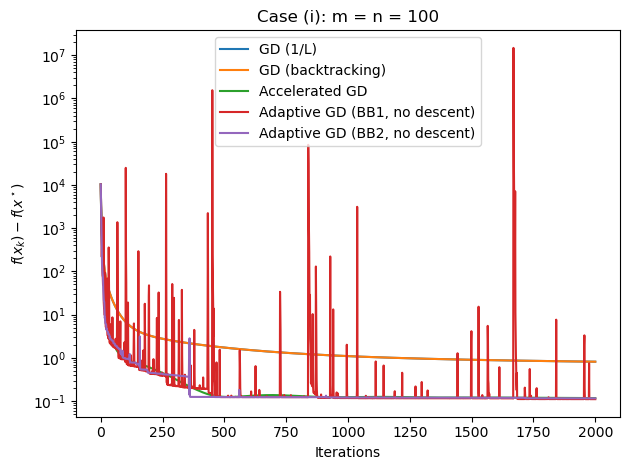

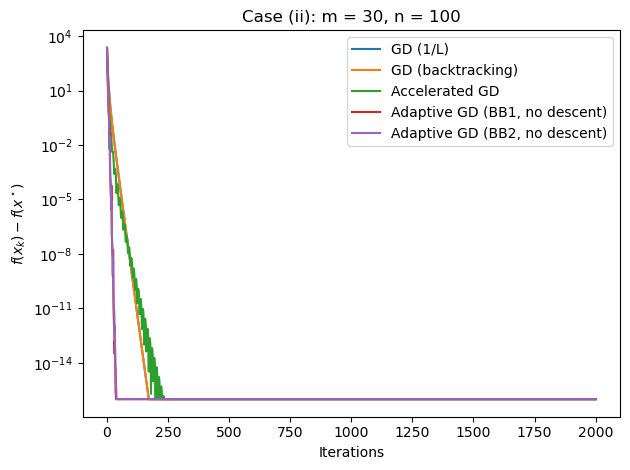

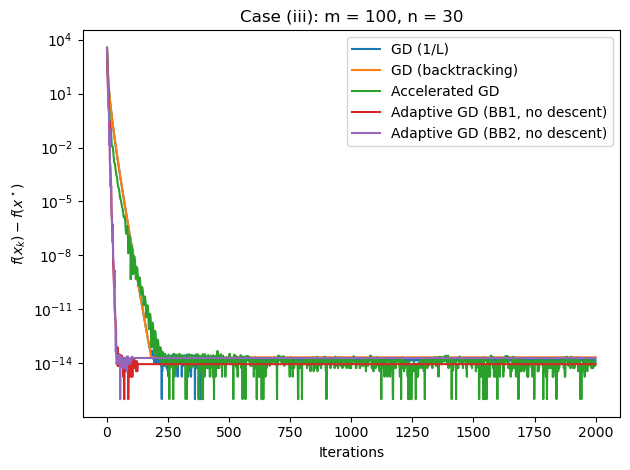

In [5]:
# Experiments
run_and_plot(100, 100, iters=2000, title="Case (i): m = n = 100")
run_and_plot(30, 100,  iters=2000, title="Case (ii): m = 30, n = 100")
run_and_plot(100, 30,  iters=2000, title="Case (iii): m = 100, n = 30")